In [2]:
import numpy as np
import pandas as pd
import os, sys, glob
import nibabel as nib
import nilearn
from nilearn import plotting
import matplotlib.pyplot as plt
import inspect
import seaborn as sns
import matplotlib
%load_ext autoreload
%autoreload 2
import brainplotlib as bpl
import utils
import config
import searchlights as sls
from nilearn.image import math_img
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from brainiak.searchlight.searchlight import Searchlight

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
mask = utils.get_mask()

In [4]:
np.where(mask != 1)

(array([0]),)

/gpfs/milgram/project/casey/elb77/conda_envs/tphate_env/lib/python3.6/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


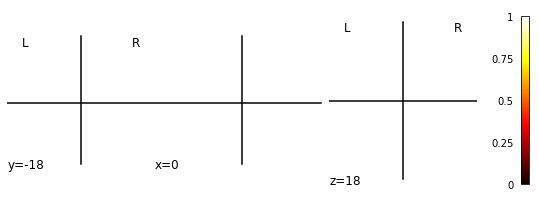

In [3]:
plotting.plot_stat_map(mask)

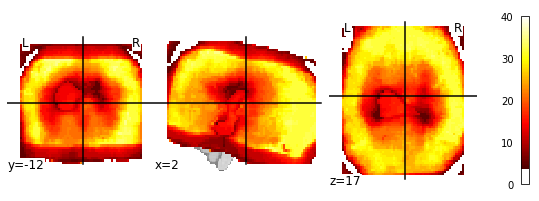

In [14]:
plotting.plot_stat_map('./StudyForrest/results/sub-01_movie_optimal_t_whole_brain_SL_rad3.nii.gz', 
                       threshold=4, vmax=40)

In [19]:
with open('vol_sl_tphate_joblist.txt', 'w') as f:
    for subject in config.SUBJECTS:
        for task in ['movie','localizer']:
            for rad in [3,5]:
                f.write(f"srun --mpi=pmi2 python -u forrest_vol_searchlight_tphate.py {subject} {task} {rad}\n")

In [5]:
data = utils.get_vol_data(1, "movie", 1, mask=True)

In [17]:
dirname = config.VOL_DATA_DIR
sub_id =1
task = 'localizer'

for sub_id in config.SUBJECTS:
    fns = sorted(glob.glob(f"{dirname}/sub-{sub_id:02d}_ses-{task}*"))

    vols = []
    for f in fns:
        nii = nib.load(f)
        vols.append(nii)

    big = math_img(f'np.concatenate([img1, img2, img3, img4], axis=3)', 
                   img1=vols[0], img2=vols[1], img3=vols[2], img4=vols[3]) 
    outfn = f'{dirname}/sub-{sub_id:02d}_ses-localizer_all_runs.nii.gz'
    print(outfn)
    nib.save(big, outfn)

/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-01_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-02_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-03_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-04_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-09_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-10_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-14_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-15_ses-localizer_all_runs.nii.gz
/gpfs/milgram/project/turk-browne/users/elb77//task_dim/StudyForrest/data/sub-16_ses-localizer_all_runs.nii.gz
/

In [16]:
big.shape

(61, 73, 56, 624)

In [12]:
for d in run_data:
    d=d[:,:,0]
    d_arr = np.mean(d, axis=0)
    print(np.min(d_arr), np.max(d_arr))

29.846153846153847 61.15384615384615
30.692307692307693 58.53846153846154
23.846153846153847 60.84615384615385
20.846153846153847 62.46153846153846
21.53846153846154 62.38461538461539
30.307692307692307 61.30769230769231
26.076923076923077 61.46153846153846
37.76923076923077 55.53846153846154


In [20]:
np.mean(arr,axis=0).max()

35.92307692307692

(13, 18742, 2)


Text(0.5, 1.0, 'Localizer')

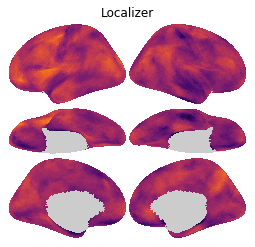

In [27]:
run_data = []
fig,ax=plt.subplots()

lh = np.array([np.load(f) for f in sorted(glob.glob(f'StudyForrest/results/sub-*localizer*lh.npy'))])
rh = np.array([np.load(f) for f in sorted(glob.glob(f'StudyForrest/results/sub-*localizer*rh.npy'))])
arr = np.concatenate([lh,rh],axis=1)
print(arr.shape)

img,scale=bpl.brain_plot(np.mean(arr,axis=0)[:,0], vmax=40, vmin=25, cmap='inferno',return_scale=True)
ax.imshow(img)
ax.axis('off')
ax.set_title(f'Localizer')

(8, 13, 18742, 2)


(-0.5, 1727.5, 1559.5, -0.5)

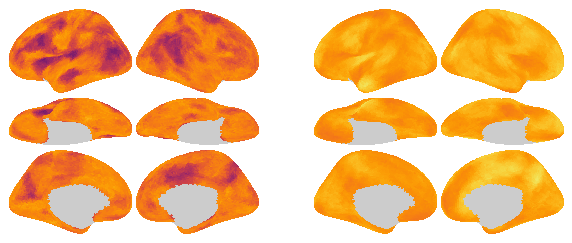

In [41]:
run_data = np.array(run_data)
print(run_data.shape)
mean_data = np.mean(run_data, axis=0)

fig,ax=plt.subplots(1,2,figsize=(10,6))

img,scale=bpl.brain_plot(np.mean(mean_data, axis=0)[:,0], vmax=64, vmin=20, cmap='inferno',return_scale=True)
ax[0].imshow(img)
ax[0].axis('off')
fig.colorbar(scale,cax=cbar_ax)

img,scale=bpl.brain_plot(np.mean(mean_data, axis=0)[:,1], vmax=8, vmin=5, cmap='inferno',return_scale=True)
ax[1].imshow(img)
ax[1].axis('off')


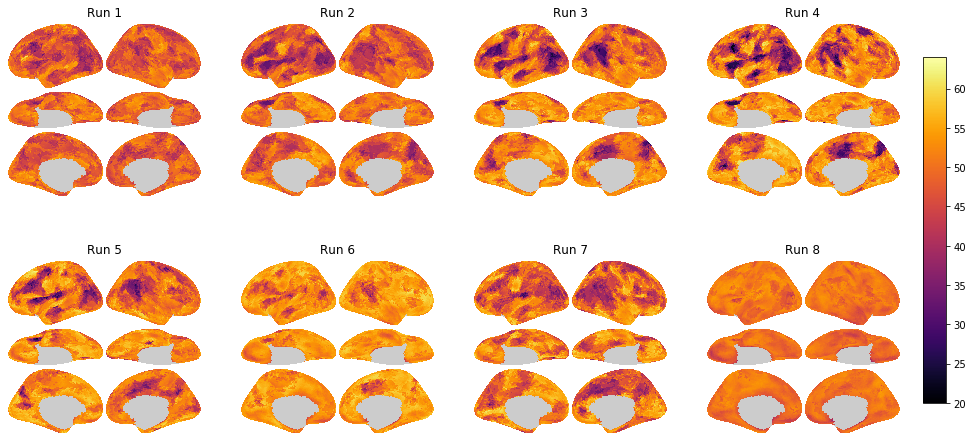

In [28]:
run_data = []
fig,ax=plt.subplots(2,4,figsize=(16,8))
ax=ax.ravel()
for a, r in zip(ax,np.arange(1,9)):
    lh = np.array([np.load(f) for f in sorted(glob.glob(f'StudyForrest/results/sub-*run-{r}_*lh.npy'))])
    rh = np.array([np.load(f) for f in sorted(glob.glob(f'StudyForrest/results/sub-*run-{r}_*rh.npy'))])
    arr = np.concatenate([lh,rh],axis=1)
    run_data.append(arr)
    
    img,scale=bpl.brain_plot(np.mean(arr,axis=0)[:,0], vmax=64, vmin=20, cmap='inferno',return_scale=True)
    a.imshow(img)
    a.axis('off')
    a.set_title(f'Run {r}')
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
fig.colorbar(scale, cax=cbar_ax)

In [17]:
s = sls.get_searchlights('l', 18) # approx equivalent number of vertices per sl

In [20]:
print(len(s), np.mean([len(s[i]) for i in range(len(s))]))

9372 130.67114810072556


In [22]:
movie_data = []
for sub in config.SUBJECTS[1:]:
    x1 = utils.get_sl_dimensionality_map(sub_num=sub, run_num=8, sl_rad=8, ses='movie', hemi='b')
    movie_data.append(x1)
movie_data = np.array(movie_data)

loc_data = []
for sub in config.SUBJECTS[1:]:
    x1 = utils.get_sl_dimensionality_map(sub_num=sub, run_num=8, sl_rad=8, ses='localizer', hemi='b')
    movie_data.append(x1)
movie_data = np.array(movie_data)

In [27]:
sub_data.min()

13

Text(0.5, 1.0, 'Run 1')

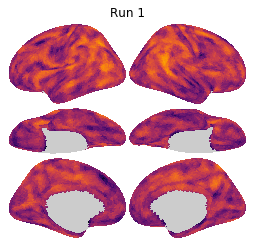

In [28]:
fig,ax=plt.subplots()
img, scale = bpl.brain_plot(np.mean(sub_data,axis=0), vmax=60, vmin=13, cmap='inferno',return_scale=True)
ax.imshow(img)
ax.axis('off')
ax.set_title(f'Run 1')

In [24]:
a = np.load('results/sub-01_ses-movie_run-01_dimensionality_lh.npy')

In [53]:
data.shape, train, test

((13, 338, 9372),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 0)

In [54]:
data = utils.get_train_data('l', [8], 'movie', z=True, mask=False)
searchlights = sls.get_searchlights('l', 18)
subject_ids = np.arange(data.shape[0])
results = np.zeros((data.shape[0], len(searchlights)))

for s,sl in enumerate(searchlights):
    this_data = data[:,:,sl]
    for test in subject_ids:
        train=np.setdiff1d(subject_ids, test)
        train_data = np.mean(this_data[train,:,:],axis=0).ravel()
        test_data = this_data[test, :, :].ravel()
        results[test, s] = np.corrcoef(train_data, test_data)[0,1]

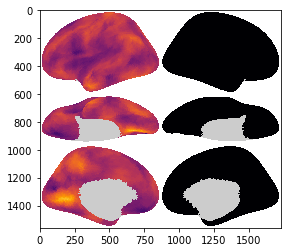

In [62]:
img, scale=bpl.brain_plot(np.concatenate((np.mean(results,axis=0),np.zeros(9370))), 
                              vmax=0.5, vmin=0, cmap='inferno',return_scale=True)
plt.imshow(img)

In [64]:
fn = '../StudyForrest/studyforrest_bids/derivatives/fmriprep/sub-01/ses-movie/func/sub-01_ses-movie_task-movie_run-1_space-MNI152Lin_desc-preproc_bold.nii.gz'
img = nib.load(fn)
print(img.shape)



(61, 73, 56, 451)


In [66]:
! cp ../StudyForrest/studyforrest_bids/derivatives/fmriprep/sub*/ses-localizer/func/*run-*MNI152Lin_desc-preproc_bold.nii.gz ./StudyForrest/data/


In [ ]:
labels = utils.load_subject_localizer_labels(1, 1)
